#### Random access binary files

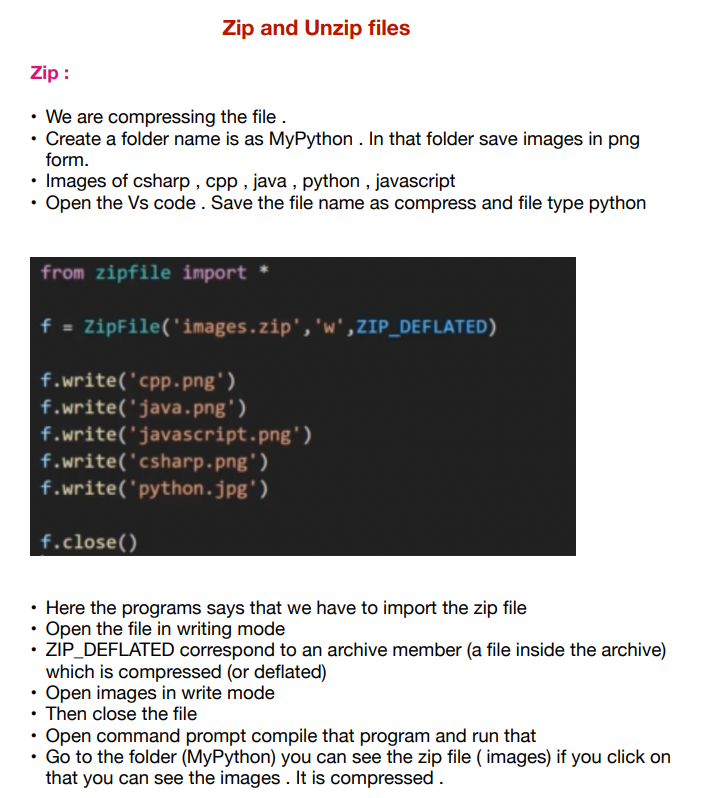

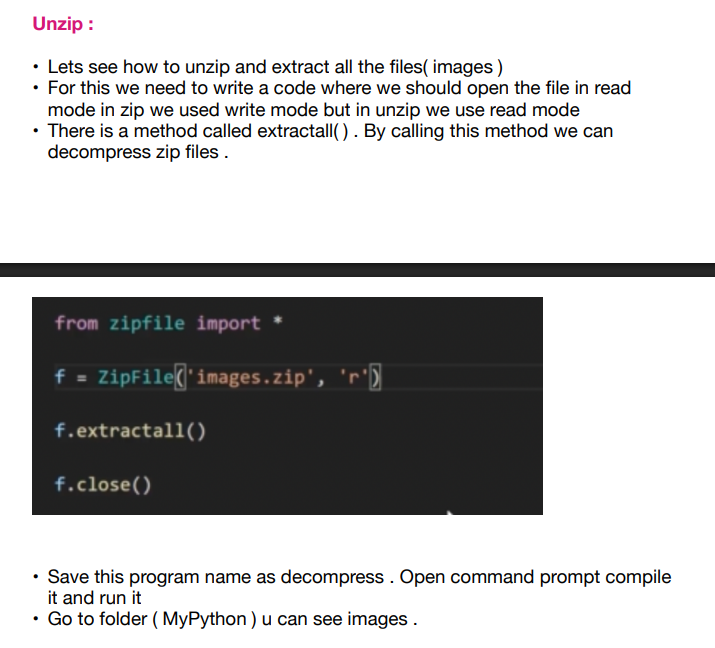

- To create binary file there is something called as struct module available in Python.
- which will help in converting the data into bytes.
- Binary files require the data only in the form of bytes

#### Format C Type   Bytes
- h - short - 2
- i - int - 4
- I - unsigned int - 4
- l - long - 8
- L - unsigned long - 8

#### Float
- f - float - 4
- d - double - 8

#### String
- s - char[]
- p - char[]
- There is no size, the size depends on the number of letters in a string.

#### Character
- c - char - 1
- b - signed char - 1
- B - unsigned char - 1
- ? - _Bool - 1

In [1]:
import struct

id = 14
name = "Smith"

with open('players.dat', mode = 'ab') as file:
    record = struct.pack('i10s' ,id, name.encode())   ## to convert the data into binary form, 
                                    ## for string to binary conversion we have to take encode function.
                                    ## we should also mention the data format before pack
                                    ## i = integer, 10s = 10 strings
    file.write(record)


In [4]:
import struct

record_size = 14

def add_player(id, name):
    with open('players.dat', mode = 'ab') as file:
        name = name.encode().ljust(10)
        record = struct.pack('i10s' ,id, name)   ## to convert the data into binary form, 
        file.write(record)

add_player(14, 'Smith')
add_player(16, 'Varun')
add_player(1, 'Ravi')
add_player(20, 'Kiran')
add_player(4, 'Ali')

##### Random access in binary file

In [5]:
## To access the record stored in index 2
index = 2

with open('players.dat', mode = 'rb') as file:
    file.seek(index * record_size)    ## must move it by the size of record bytes i.e. 14 bytes
    record = file.read(record_size)

    id, name = struct.unpack('i10s', record)   ## unpacking the record using formatting string 'i10s'
    print(f"ID: {id}, Name: {name.decode()}")

## Whenever you are writing string, while packing use encode and while unpacking use decode

ID: 16, Name: Varun     


In [2]:
## to create a binary file
import struct

record_size = 14

def add_player(id, name):
    with open('players.dat', mode = 'ab') as file:
        name = name.encode().ljust(10)
        record = struct.pack('i10s' ,id, name)   ## to convert the data into binary form, 
        file.write(record)


## To access the record (random access binary file)
def find(index):

    with open('players.dat', mode = 'rb') as file:
        file.seek(index * record_size)    ## must move it by the size of record bytes i.e. 14 bytes
        record = file.read(record_size)

        if record:
            id, name = struct.unpack('i10s', record)   ## unpacking the record using formatting string 'i10s'
            print(f"ID: {id}, Name: {name.decode()}")
        else:
            print("No record at that index.")

# add_player(14, 'Smith')
# add_player(16, 'Varun')
# add_player(1, 'Ravi')
# add_player(20, 'Kiran')
# add_player(4, 'Ali')

find(2)

ID: 1, Name: Ravi      
